# Improved Machine Learning Model for Adverse Outcome Prediction
Author: Data Science Team
Date: Spring 2026

This notebook demonstrates exploratory data analysis and uses Logistic Regression, Random Forest, and XGBoost to predict severe outcomes based on the provided healthcare dataset.


In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, precision_recall_curve, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix, hstack

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


## 2. Load and Inspect Data


In [2]:
# Load enriched dataset
try:
    df = pd.read_excel('all02072026_belle02152026.xlsx')
    print(f"Data loaded successfully. Shape: {df.shape}")
except Exception as e:
    print(f"Error loading file: {e}")

df.head(3)


Data loaded successfully. Shape: (20627, 194)


,Case ID,Target_Drug,Serious_Reports,Died,FDA_Approval_Date,Earliest Event Date,Days_From_Approval,Months_From_Approval,Years_From_Approval,Event Date,...,Concomitant Product Names_34,Concomitant Product Names_35,Concomitant Product Names_36,Concomitant Product Names_37,Country where Event occurred,Event_Country,Reported to Manufacturer?,Manufacturer Control Number,Literature Reference,Compounded Flag
0,17977166,Alecensa,1,0,2014-04-29,2020-05-21,2214,72,6,2020-05-21 00:00:00,...,NaN,NaN,NaN,NaN,JP,Japan,Not Specified,JPROCHE2629148,"HIROTA H, Nakajima H, Nakajima K, et al. A Cas...",NaN
1,18354541,Xalkori,1,0,2011-11-26,2006-10-06,-1877,0,0,2006-10-06 00:00:00,...,NaN,NaN,NaN,NaN,US,United States,Not Specified,NaN,NaN,NaN
2,23363462,Xalkori,1,0,2011-11-26,2023-12-10,4397,144,12,2023-12-10 00:00:00,...,NaN,NaN,NaN,NaN,CN,China,Not Specified,CNPFIZER INCPV202300207774,NaN,NaN


## 3. Exploratory Data Analysis (EDA)
Visualizing the target variable (`Serious_Reports`) and the relationship with Key Features (e.g. `Age_Year`, `Pt Weight_lbs`).


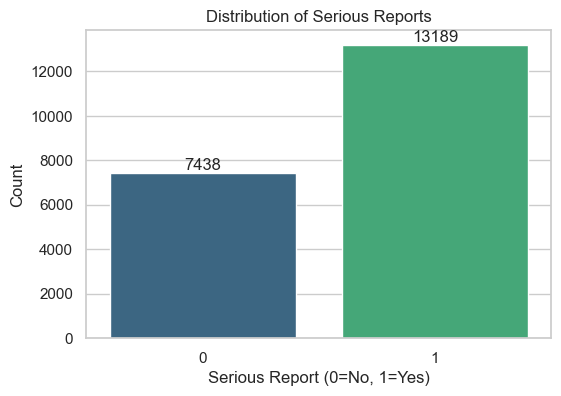

In [3]:
# Visualize Target Variable
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='Serious_Reports', palette='viridis')
plt.title('Distribution of Serious Reports')
plt.xlabel('Serious Report (0=No, 1=Yes)')
plt.ylabel('Count')

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.show()


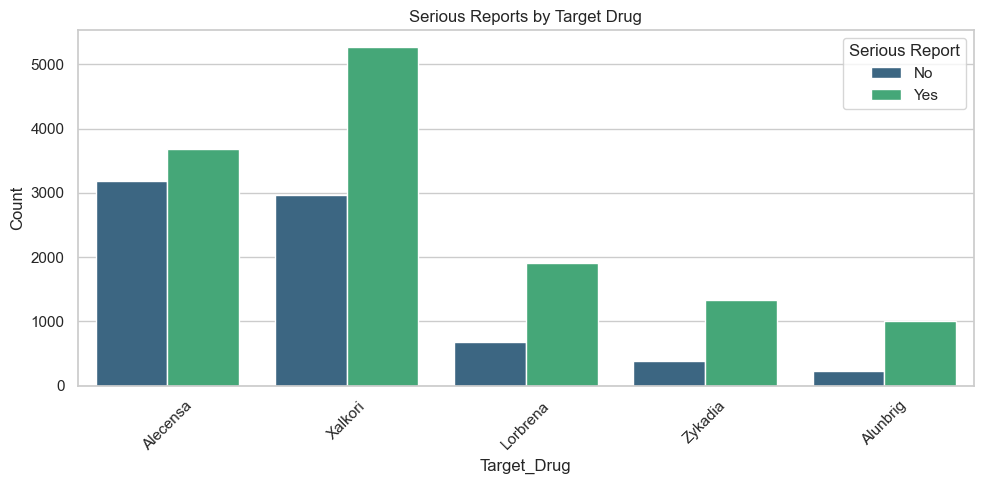

In [4]:
# Visualizing Target by Drug Target
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Target_Drug', hue='Serious_Reports', palette='viridis')
plt.title('Serious Reports by Target Drug')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Serious Report', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()


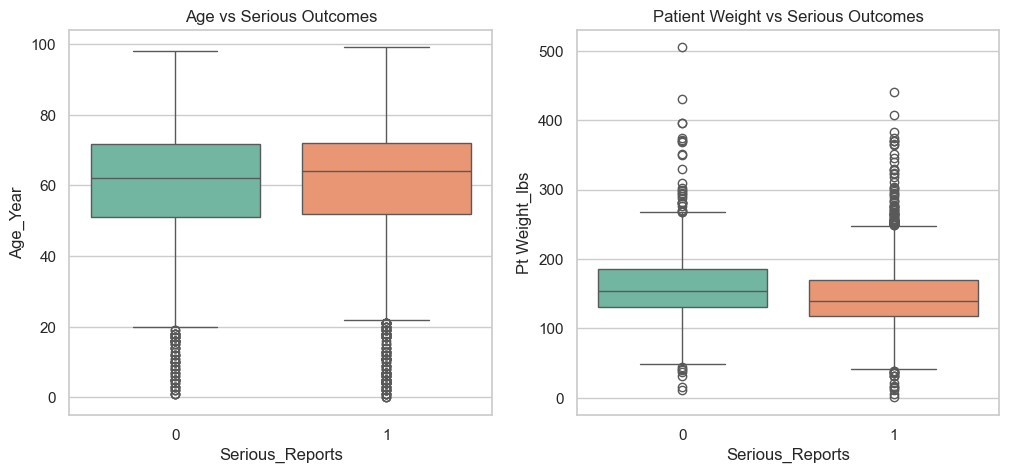

In [5]:
# Scatter/Box plot of Age and Weight
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df, x='Serious_Reports', y='Age_Year', ax=ax[0], palette='Set2')
ax[0].set_title('Age vs Serious Outcomes')

sns.boxplot(data=df, x='Serious_Reports', y='Pt Weight_lbs', ax=ax[1], palette='Set2')
ax[1].set_title('Patient Weight vs Serious Outcomes')
plt.show()


## 4. Data Preparation & Feature Engineering


In [6]:
# Select features
numeric_features = ['Age_Year', 'Pt Weight_lbs', 'Months_From_Approval']
categorical_features = ['Sex', 'Case Priority', 'Reporter Type', 'Target_Drug', 'Event_Country']

# Handling missing values
for col in numeric_features:
    # Fill numeric NaNs with median
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

for col in categorical_features:
    df[col] = df[col].fillna('Unknown')

# Define labels/predictors
y = df['Serious_Reports'].astype(int)

# Extract text features safely
df['Reactions'] = df['Reactions'].fillna('')
df['Concomitant Product Names'] = df['Concomitant Product Names'].fillna('')

X_structured = df[numeric_features + categorical_features].copy()


In [7]:
# One-Hot Encode Categorical features
X_structured_encoded = pd.get_dummies(X_structured, columns=categorical_features, drop_first=True, dtype=float)

# Create a list of columns that start with either prefix
cols_to_drop = [c for c in X_structured_encoded.columns if c.startswith('Case Priority_') or 
                c.startswith('Event_Country_') or
                c.startswith('Reporter Type_') or
                c.startswith('Reaction')]

# Drop them from the encoded dataframe
X_structured_encoded = X_structured_encoded.drop(columns=cols_to_drop)

# TF-IDF on Reactions
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
custom_stop_words = list(ENGLISH_STOP_WORDS) + ['death', 'event']
tfidf_reactions = TfidfVectorizer(max_features=400, stop_words=custom_stop_words)
X_reactions = tfidf_reactions.fit_transform(df['Reactions'])

# TF-IDF on Concomitant
tfidf_concomitant = TfidfVectorizer(max_features=100, stop_words='english')
X_concomitant = tfidf_concomitant.fit_transform(df['Concomitant Product Names'])

# Combine Features
X_dense_sparse = csr_matrix(X_structured_encoded.values)
X_final = hstack([X_dense_sparse, X_reactions, X_concomitant])

print(f"Final feature matrix shape: {X_final.shape}")


Final feature matrix shape: (20627, 509)


## 5. Model Training
We use an 80/20 train-test split. We'll train Logistic Regression, Random Forest, and XGBoost using class weights to manage class imbalance.


In [8]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape[0]} samples\nTest set: {X_test.shape[0]} samples")


Train set: 16501 samples
Test set: 4126 samples


In [9]:
# Initialize Models
# class_weight='balanced' handles imbalanced sets
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# XGBoost weight adjustment
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1.0
xgb = XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight, random_state=42, use_label_encoder=False, eval_metric='logloss')

# Train Models
print("Training Logistic Regression...")
lr.fit(X_train, y_train)

print("Training Random Forest...")
rf.fit(X_train, y_train)

print("Training XGBoost...")
xgb.fit(X_train, y_train)

print("Training complete!")


Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training complete!


## 6. Model Evaluation
Evaluate the models using classification reports, ROC-AUC, and PR-AUC.


In [10]:
# Generate predictions
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}\n")
    return y_prob

y_prob_lr = evaluate_model(lr, "Logistic Regression")
y_prob_rf = evaluate_model(rf, "Random Forest")
y_prob_xgb = evaluate_model(xgb, "XGBoost")


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.68      0.81      0.74      1488
           1       0.88      0.79      0.83      2638

    accuracy                           0.80      4126
   macro avg       0.78      0.80      0.79      4126
weighted avg       0.81      0.80      0.80      4126

ROC-AUC: 0.8647 | PR-AUC: 0.9144

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.76      0.76      0.76      1488
           1       0.86      0.87      0.86      2638

    accuracy                           0.83      4126
   macro avg       0.81      0.81      0.81      4126
weighted avg       0.83      0.83      0.83      4126

ROC-AUC: 0.8967 | PR-AUC: 0.9350

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.75      0.82      0.78      1488
           1       0.89      0.84      0.87      2638

    accuracy                           0.83     

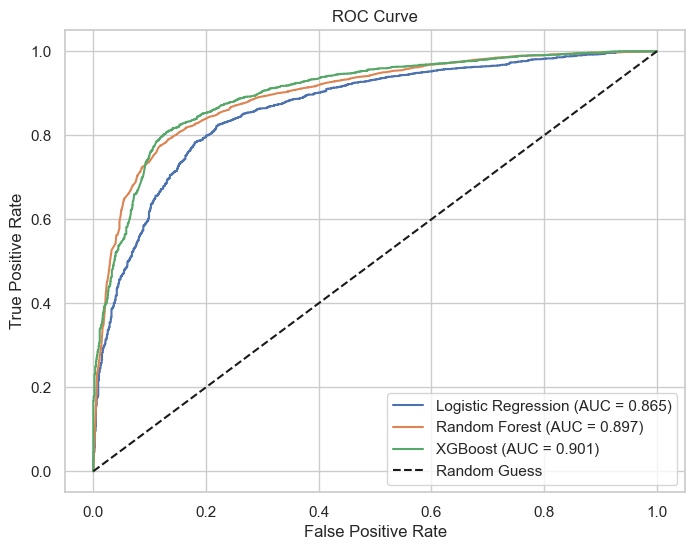

In [11]:
# ROC Curve Visualization
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})")
plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.show()


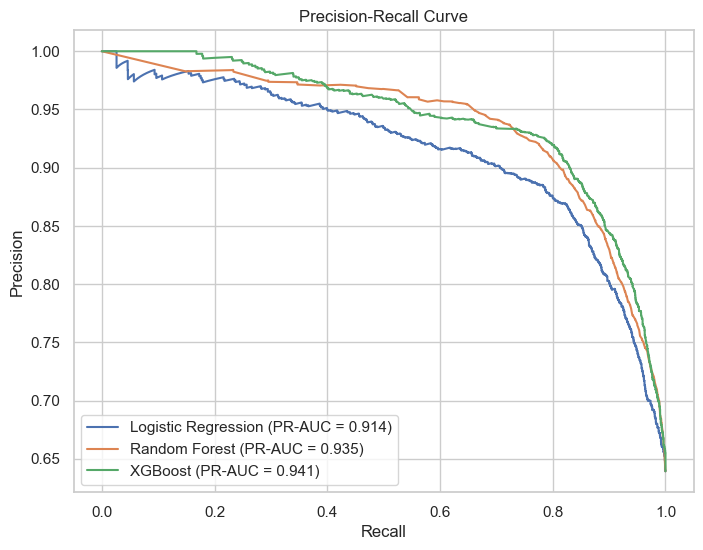

In [12]:
# Precision-Recall Curve Visualization
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))
plt.plot(rec_lr, prec_lr, label=f"Logistic Regression (PR-AUC = {average_precision_score(y_test, y_prob_lr):.3f})")
plt.plot(rec_rf, prec_rf, label=f"Random Forest (PR-AUC = {average_precision_score(y_test, y_prob_rf):.3f})")
plt.plot(rec_xgb, prec_xgb, label=f"XGBoost (PR-AUC = {average_precision_score(y_test, y_prob_xgb):.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc='lower left')
plt.show()


## 7. Feature Importance (XGBoost)
Identifying what drives severe outcome predictions provides actionable insights for stakeholders.


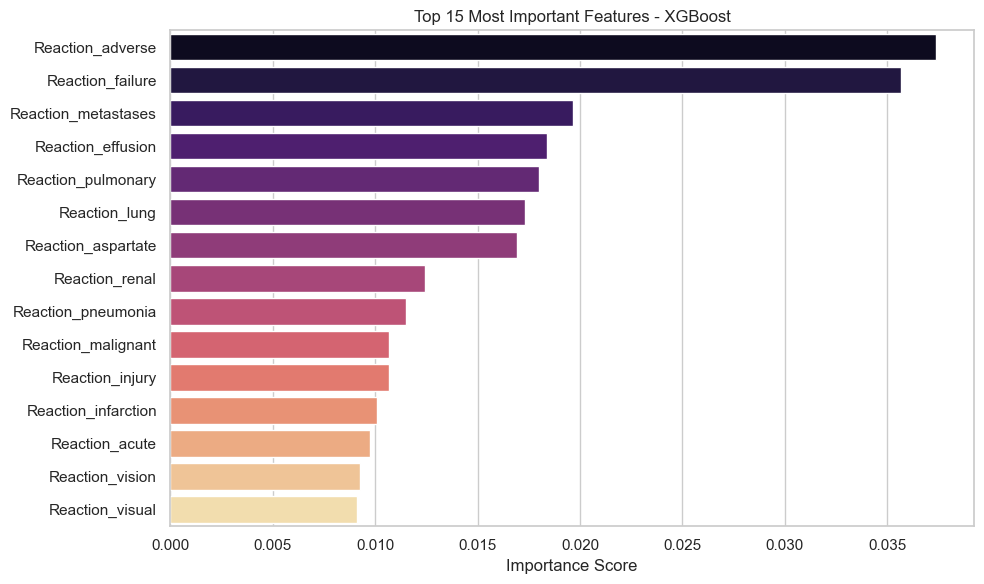

In [14]:
# Extract Feature Names
structured_feature_names = X_structured_encoded.columns.tolist()
reaction_feature_names = [f"Reaction_{w}" for w in tfidf_reactions.get_feature_names_out()]
concomitant_feature_names = [f"Concomitant_{w}" for w in tfidf_concomitant.get_feature_names_out()]
all_feature_names = structured_feature_names + reaction_feature_names + concomitant_feature_names

# Get feature importance from XGBoost
importances = xgb.feature_importances_
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
plt.title("Top 15 Most Important Features - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("")
plt.tight_layout()
plt.show()
